In [ ]:
import sys
import torch
import pytorch_lightning as pl
import pathlib
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
if str(PROJECT_ROOT / "src" / "fresh_attempt") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src" / "fresh_attempt"))

from config import CFG, Config, DISEASE_LABELS
from datamodule import ChestXrayDataModule
from model import ChestXrayClassifier

if hasattr(torch.serialization, 'add_safe_globals'):
    torch.serialization.add_safe_globals([
        Config,
        pathlib.Path,
        pathlib.PosixPath,
        pathlib.WindowsPath
    ])

CKPT_PATH = str(PROJECT_ROOT / "checkpoints" / "centralized_baseline" / "last.ckpt")

datamodule = ChestXrayDataModule(cfg=CFG)
datamodule.setup()

id_loader = datamodule.test_dataloader()
ood_loader = datamodule.ood_dataloader()

model = ChestXrayClassifier.load_from_checkpoint(CKPT_PATH, cfg=CFG, strict=False)
model.eval()

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision=CFG.precision,
    logger=False,
)

print("Running inference on ID and OOD sets...")
raw_results = trainer.test(model=model, dataloaders=[id_loader, ood_loader], verbose=False)

id_results = raw_results[0]
ood_results = raw_results[1]
print("Inference complete. Ready for plotting.")

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA RTX 4000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Running inference on ID and OOD sets...


Output()

/s/chopin/k/grad/jasoncur/.local/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No 
positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive 
score
  warnings.warn(*args, **kwargs)

Inference complete. Ready for plotting.


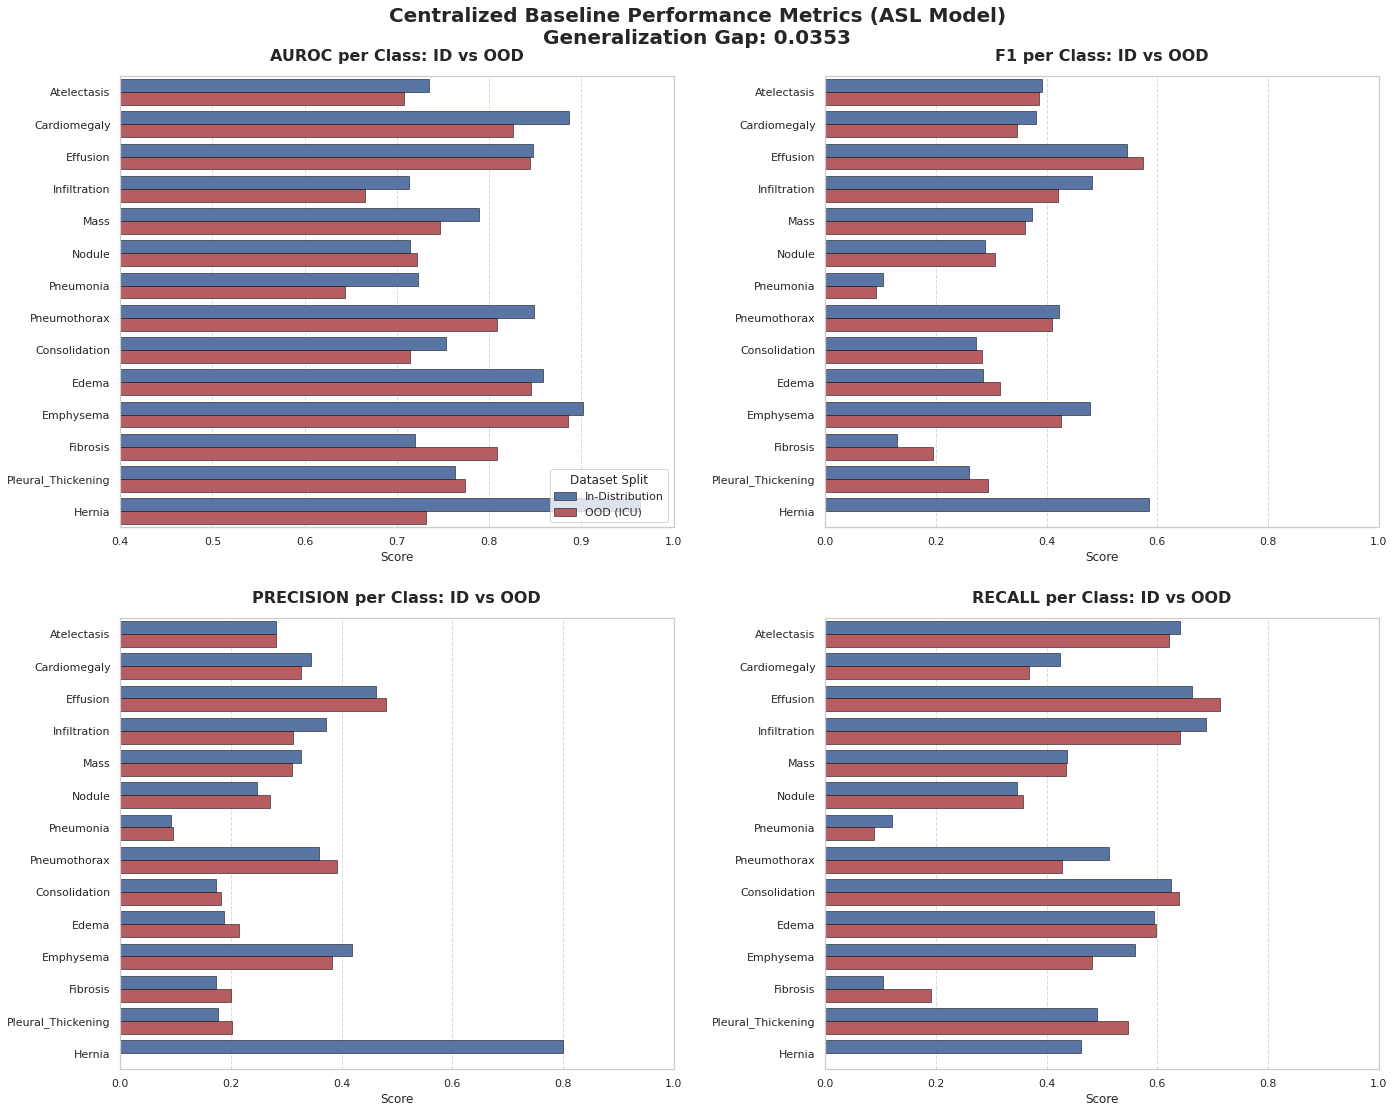

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics = ['auroc', 'f1', 'precision', 'recall']
rows = []

for disease in DISEASE_LABELS:
    for metric in metrics:
        # Extract ID metrics
        id_val = id_results.get(f'test_id/{metric}_{disease}', np.nan)
        rows.append({'Disease': disease, 'Metric': metric.upper(), 'Split': 'In-Distribution', 'Score': id_val})

        # Extract OOD metrics
        ood_val = ood_results.get(f'test_ood/{metric}_{disease}', np.nan)
        rows.append({'Disease': disease, 'Metric': metric.upper(), 'Split': 'OOD (ICU)', 'Score': ood_val})

df = pd.DataFrame(rows)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

palette = {"In-Distribution": "#4C72B0", "OOD (ICU)": "#C44E52"}

for i, metric in enumerate(['AUROC', 'F1', 'PRECISION', 'RECALL']):
    ax = axes[i]
    metric_data = df[df['Metric'] == metric]

    sns.barplot(
        data=metric_data,
        y='Disease',
        x='Score',
        hue='Split',
        ax=ax,
        palette=palette,
        edgecolor='black',
        linewidth=0.5
    )

    ax.set_title(f'{metric} per Class: ID vs OOD', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Score', fontsize=12)
    ax.set_ylabel('')

    if metric == 'AUROC':
        ax.set_xlim(0.4, 1.0)
    else:
        ax.set_xlim(0.0, 1.0)

    ax.tick_params(axis='y', labelsize=11)

    ax.xaxis.grid(True, linestyle='--', alpha=0.7)

    if i == 0:
        ax.legend(title='Dataset Split', loc='lower right', frameon=True, fontsize=11)
    else:
        ax.get_legend().remove()

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.92)
fig.suptitle(f'Centralized Baseline Performance Metrics (ASL Model)\nGeneralization Gap: {id_results.get("test/ood_generalization_gap_auroc", 0):.4f}',
             fontsize=20, fontweight='bold')

plt.show()

# fig.savefig("centralized_baseline_metrics.png", dpi=300, bbox_inches='tight')